# 03 — NMF Topic Modeling on BIS Central Bank Speeches

This notebook applies a first topic modeling method to the preprocessed BIS central bank speeches corpus.

The objective is to build a strong and interpretable baseline using:

1. TF-IDF vectorization;
2. Non-negative Matrix Factorization (NMF);
3. topic interpretation through top words;
4. temporal analysis of topic prevalence;
5. topic prevalence by macro-financial period.

NMF is used here as a classical and interpretable baseline before comparing it with LDA and BERTopic in the next notebooks.


## 1. Imports

I import the libraries needed for data manipulation, visualization, TF-IDF vectorization and NMF topic modeling.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import normalize

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 180)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load the preprocessed corpus

The previous notebook saved the final modeling corpus as `bis_speeches_preprocessed.csv`.

If the file is not found, check that the preprocessing notebook was run in the same working directory as this notebook.


In [2]:
# Check the current working directory
print("Current working directory:", os.getcwd())

# List available CSV files in the current folder
csv_files = [f for f in os.listdir(".") if f.endswith(".csv")]
print("CSV files in current directory:", csv_files)


Current working directory: /content
CSV files in current directory: []


In [3]:
# from google.colab import files
# uploaded = files.upload()

In [4]:
from google.colab import drive
drive.mount("/content/drive")

DATA_PATH = "/content/drive/MyDrive/Data/bis_speeches_preprocessed_CB.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Mounted at /content/drive
Shape: (18922, 11)


,description,raw_text_stripped,clean_text,bertopic_text,central_bank,year,month,macro_period,n_words_raw,n_characters_raw,n_words_clean
0,"Lecture delivered in honour of Professor Xenophon Zolotas, Honorary Governor of the Bank of Greece, by the President of the Deutsche Bundesbank, Prof. Hans Tietmeyer, in Athens...","Mr. Tietmeyer considers European monetary integration and its implications for the international monetary system Lecture delivered in honour of Professor Xenophon Zolotas, Hono...",tietmeyer consider european monetary integration implication international monetary lecture deliver honour professor xenophon zolotas honorary greece president deutsche bundesb...,"Mr. Tietmeyer considers European monetary integration and its implications for the international monetary system Lecture delivered in honour of Professor Xenophon Zolotas, Hono...",bank of greece,1997,10,Pre-GFC,5070,31212,2078
1,"Speech given by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at the 'Athens Summit 1999' on 18 September 1999.","Mr Garganas gives a speech on integrating Greece into the euro area and the challenges ahead Speech given by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at t...",garganas integrate greece euro area challenge nicholas garganas greece athens summit september adoption euro common currency group european union member state january historic ...,"Mr Garganas gives a speech on integrating Greece into the euro area and the challenges ahead Speech given by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at t...",bank of greece,1999,9,Pre-GFC,2307,14497,1096
2,"Speech by Mr Lucas Papademos, Governor of the Bank of Greece, at the Euro Information Conference, Athens, 17 October 2001.","Lucas Papademos: The completion of the changeover to the euro Speech by Mr Lucas Papademos, Governor of the Bank of Greece, at the Euro Information Conference, Athens, 17 Octob...",lucas papademos completion changeover euro lucas papademos greece euro information athens october welcome session euro information presence attest importance attach successful ...,"Lucas Papademos: The completion of the changeover to the euro Speech by Mr Lucas Papademos, Governor of the Bank of Greece, at the Euro Information Conference, Athens, 17 Octob...",bank of greece,2001,10,Pre-GFC,2975,18231,1213
3,"Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, to the Hellenic American Bankers Association, New York, 23 April 2002.","Nicholas Garganas: The Greek economy within the euro area Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, to the Hellenic American Bankers Association...",nicholas garganas greek economy euro area nicholas garganas greece hellenic american bankers association york april great pleasure able transformation greek economy beginning g...,"Nicholas Garganas: The Greek economy within the euro area Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, to the Hellenic American Bankers Association...",bank of greece,2002,5,Pre-GFC,2129,13387,1008
4,"Speech by Mr Nicholas C Garganas, Governor of the Bank of Greece, at The Economist Conference: Private Banking and Asset Management, Athens, 22 October 2002.","Nicholas C Garganas: The European financial marketplace Speech by Mr Nicholas C Garganas, Governor of the Bank of Greece, at The Economist Conference: Private Banking and Asset...",nicholas garganas european financial marketplace nicholas garganas greece economist private banking asset management athens october lady gentleman let start thank economist inv...,"Nicholas C Garganas: The European financial marketplace Speech by Mr Nicholas C Garganas, Governor of the Bank of Greece, at The Economist Conference: Private Banking and Asset...",bank of greece,2002,10,Pre-GFC,2001,13166,982


The corpus contains one row per speech. The most important columns for this notebook are:

- `clean_text`: aggressively cleaned text used for TF-IDF and NMF;
- `year`: year of the speech;
- `macro_period`: manually defined macro-financial period;
- `central_bank`: institution associated with the speech.


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18922 entries, 0 to 18921
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   description        18922 non-null  object
 1   raw_text_stripped  18922 non-null  object
 2   clean_text         18922 non-null  object
 3   bertopic_text      18922 non-null  object
 4   central_bank       18922 non-null  object
 5   year               18922 non-null  int64 
 6   month              18922 non-null  int64 
 7   macro_period       18922 non-null  object
 8   n_words_raw        18922 non-null  int64 
 9   n_characters_raw   18922 non-null  int64 
 10  n_words_clean      18922 non-null  int64 
dtypes: int64(5), object(6)
memory usage: 1.6+ MB


In [6]:
# Basic sanity checks
print("Number of speeches:", len(df))
print("Minimum year:", df["year"].min())
print("Maximum year:", df["year"].max())
print("Number of central banks:", df["central_bank"].nunique())
print("Missing clean_text:", df["clean_text"].isna().sum())

df[["clean_text", "year", "macro_period", "central_bank", "n_words_clean"]].head()


Number of speeches: 18922
Minimum year: 1997
Maximum year: 2025
Number of central banks: 118
Missing clean_text: 0


,clean_text,year,macro_period,central_bank,n_words_clean
0,tietmeyer consider european monetary integration implication international monetary lecture deliver honour professor xenophon zolotas honorary greece president deutsche bundesb...,1997,Pre-GFC,bank of greece,2078
1,garganas integrate greece euro area challenge nicholas garganas greece athens summit september adoption euro common currency group european union member state january historic ...,1999,Pre-GFC,bank of greece,1096
2,lucas papademos completion changeover euro lucas papademos greece euro information athens october welcome session euro information presence attest importance attach successful ...,2001,Pre-GFC,bank of greece,1213
3,nicholas garganas greek economy euro area nicholas garganas greece hellenic american bankers association york april great pleasure able transformation greek economy beginning g...,2002,Pre-GFC,bank of greece,1008
4,nicholas garganas european financial marketplace nicholas garganas greece economist private banking asset management athens october lady gentleman let start thank economist inv...,2002,Pre-GFC,bank of greece,982


In [7]:
# Check that the corrected preprocessing was used
protected_terms = [
    "monetary_policy",
    "financial_stability",
    "price_stability",
    "interest_rate",
    "exchange_rate",
    "federal_reserve",
    "euro_area",
    "climate_change",
    "basel_iii",
    "covid19"
]

for term in protected_terms:
    count = df["clean_text"].fillna("").str.contains(term, regex=False).sum()
    print(f"{term}: {count} documents")

monetary_policy: 1 documents
financial_stability: 2 documents
price_stability: 0 documents
interest_rate: 0 documents
exchange_rate: 0 documents
federal_reserve: 0 documents
euro_area: 1 documents
climate_change: 3 documents
basel_iii: 0 documents
covid19: 1286 documents


## 3. TF-IDF representation

NMF needs a document-term matrix. I use TF-IDF because it gives more importance to words that are frequent in a document but not too frequent in the whole corpus.

This is useful for topic modeling because very common words are less informative, while more specific words help identify themes.

The parameters are chosen as follows:

- `max_df=0.85`: remove terms that appear in more than 85% of documents;
- `min_df=20`: remove very rare terms appearing in fewer than 20 documents;
- `max_features=10000`: keep the 10,000 most informative terms;
- `ngram_range=(1, 2)`: use both single words and bigrams such as `price stability` or `monetary policy`.


In [8]:
vectorizer = TfidfVectorizer(
    max_df=0.85,
    min_df=20,
    max_features=10000,  #Dans le cours, voc autour de 10k est une valeur courante pour des rep BOW. garde assez d’info sans rendre la matrice énorme.
    ngram_range=(1, 2)
    #- `ngram_range=(1, 2)`: use both single tokens and bigrams. Some important economic expressions such as `monetary_policy`, `financial_stability`, `price_stability`,
    #`exchange_rate`, and `federal_reserve` were already protected during preprocessing, while the vectorizer can still capture additional frequent bigrams.
)

X_tfidf = vectorizer.fit_transform(df["clean_text"].fillna(""))

feature_names = np.array(vectorizer.get_feature_names_out())

print("TF-IDF matrix shape:", X_tfidf.shape)
print("Number of documents:", X_tfidf.shape[0])
print("Vocabulary size:", X_tfidf.shape[1])


TF-IDF matrix shape: (18922, 10000)
Number of documents: 18922
Vocabulary size: 10000


The TF-IDF matrix has one row per speech and one column per selected word or bigram. This sparse matrix is the input for the NMF topic model.


In [9]:
# Inspect some vocabulary terms
feature_names[:50]


array(['10th', '19th', '19th century', '1st', '20th', '20th century',
       '21st', '21st century', '2nd', '3rd', '4th', 'aaa', 'abandon',
       'abate', 'ability', 'able', 'able meet', 'able provide', 'abolish',
       'abrupt', 'abs', 'absence', 'absent', 'absolute', 'absorb',
       'absorb loss', 'absorb shock', 'absorption', 'abstract',
       'abundance', 'abundant', 'abuse', 'academia', 'academic',
       'academic research', 'academy', 'accelerate', 'accelerated',
       'acceleration', 'accelerator', 'accentuate', 'accept',
       'acceptable', 'acceptance', 'access', 'access capital',
       'access credit', 'access finance', 'access financial',
       'access financing'], dtype=object)

## 4. Helper functions for topic display

I define helper functions to fit an NMF model and display the most important words for each topic.


In [10]:
def get_top_words(model, feature_names, n_top_words=15):
    """Return the top words for each topic of a fitted NMF model."""
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[::-1][:n_top_words]
        top_terms = feature_names[top_indices]
        top_weights = topic[top_indices]

        for rank, (term, weight) in enumerate(zip(top_terms, top_weights), start=1):
            topics.append({
                "topic": topic_idx,
                "rank": rank,
                "term": term,
                "weight": weight
            })

    return pd.DataFrame(topics)


def display_topics(topic_words_df, n_topics):
    """Display top terms for each topic in a readable format."""
    for topic_idx in range(n_topics):
        terms = topic_words_df.loc[
            topic_words_df["topic"] == topic_idx, "term"
        ].tolist()
        print(f"Topic {topic_idx}: " + ", ".join(terms))


def compute_topic_diversity(topic_words_df, top_n=10):
    """
    Compute topic diversity as the share of unique words among the top-N words
    of all topics. A higher value means less redundancy between topics.
    """
    top_words = topic_words_df[topic_words_df["rank"] <= top_n]["term"].tolist()

    if len(top_words) == 0:
        return np.nan

    return len(set(top_words)) / len(top_words)


## 5. Fit NMF for several numbers of topics

The number of topics is a key hyperparameter. I test several values and inspect the resulting top words.

The objective is not only to minimize a numerical criterion, but also to obtain topics that are economically interpretable and not too redundant.


In [12]:
#On test plusieurs vakeurs de K: Si K est trop petit :les topics sont trop généraux. ET Si K est trop grand :les topics deviennent redondants ou trop spécifiques
#On teste donc plusieurs valeurs et on choisit selon :l’interprétabilité ;la cohérence économique ;la faible redondance ;un bon équilibre entre détail et stabilité.
candidate_k = [4,6, 8, 10, 12,15,20]

nmf_models = {}
topic_tables = {}
reconstruction_errors = []

for k in candidate_k:
    print(f"\nFitting NMF with {k} topics...")

    nmf = NMF(
        n_components=k,
        init="nndsvda",
        random_state=RANDOM_STATE,
        max_iter=500
    )

    W = nmf.fit_transform(X_tfidf)
    H = nmf.components_

    nmf_models[k] = {
        "model": nmf,
        "W": W,
        "H": H
    }

    topic_words = get_top_words(nmf, feature_names, n_top_words=15)
    topic_tables[k] = topic_words

    topic_diversity = compute_topic_diversity(topic_words, top_n=10)

    reconstruction_errors.append({
        "n_topics": k,
        "reconstruction_error": nmf.reconstruction_err_,
        "topic_diversity_top10": topic_diversity
    })

    print(f"Reconstruction error: {nmf.reconstruction_err_:.2f}")
    display_topics(topic_words, k)



Fitting NMF with 4 topics...
Reconstruction error: 126.14
Topic 0: inflation, rate, price, monetary, monetary policy, growth, percent, target, cent, increase, low, high, term, demand, rise
Topic 1: risk, capital, crisis, banking, institution, credit, liquidity, basel, regulation, financial stability, management, asset, supervision, regulatory, stability
Topic 2: euro, euro area, area, european, ecb, monetary, union, country, europe, fiscal, monetary policy, stability, monetary union, crisis, growth
Topic 3: payment, service, digital, technology, sector, inclusion, bsp, islamic, financial inclusion, banking, customer, industry, innovation, development, growth

Fitting NMF with 6 topics...
Reconstruction error: 124.83
Topic 0: inflation, monetary, monetary policy, rate, price, target, inflation target, expectation, forecast, low, stability, inflation expectation, price stability, riksbank, high
Topic 1: risk, crisis, banking, capital, institution, basel, supervision, financial stability

## 6. Compare reconstruction error

The reconstruction error measures how well the NMF decomposition approximates the original TF-IDF matrix. A lower value means a better matrix approximation.

However, topic modeling is mainly an interpretability task. Therefore, I use this metric only as a diagnostic and choose the final number of topics based on both reconstruction error and topic interpretability.


In [13]:
reconstruction_df = pd.DataFrame(reconstruction_errors)
reconstruction_df
#Plus l’erreur est faible, plus W × H approxime bien la matrice TF-IDF.
#Choix de K ; interprétables , stables, non redondants, économiquement cohérents

,n_topics,reconstruction_error,topic_diversity_top10
0,4,126.135696,0.950000
1,6,124.825932,0.883333
2,8,123.745125,0.900000
3,10,122.722334,0.870000
4,12,121.861307,0.841667
5,15,120.627641,0.846667
6,20,118.841550,0.810000


In [14]:
reconstruction_df = pd.DataFrame(reconstruction_errors)

reconstruction_df["error_decrease"] = (
    reconstruction_df["reconstruction_error"].shift(1)
    - reconstruction_df["reconstruction_error"]
)

reconstruction_df["topics_added"] = (
    reconstruction_df["n_topics"]
    - reconstruction_df["n_topics"].shift(1)
)

reconstruction_df["decrease_per_added_topic"] = (
    reconstruction_df["error_decrease"]
    / reconstruction_df["topics_added"]
)

reconstruction_df

,n_topics,reconstruction_error,topic_diversity_top10,error_decrease,topics_added,decrease_per_added_topic
0,4,126.135696,0.950000,NaN,NaN,NaN
1,6,124.825932,0.883333,1.309764,2.0,0.654882
2,8,123.745125,0.900000,1.080807,2.0,0.540403
3,10,122.722334,0.870000,1.022791,2.0,0.511395
4,12,121.861307,0.841667,0.861027,2.0,0.430514
5,15,120.627641,0.846667,1.233666,3.0,0.411222
6,20,118.841550,0.810000,1.786091,5.0,0.357218


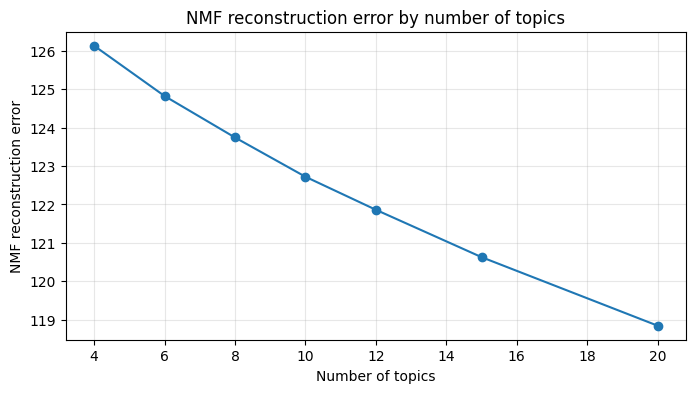

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(reconstruction_df["n_topics"], reconstruction_df["reconstruction_error"], marker="o")
plt.xlabel("Number of topics")
plt.ylabel("NMF reconstruction error")
plt.title("NMF reconstruction error by number of topics")
plt.grid(alpha=0.3)
plt.show()


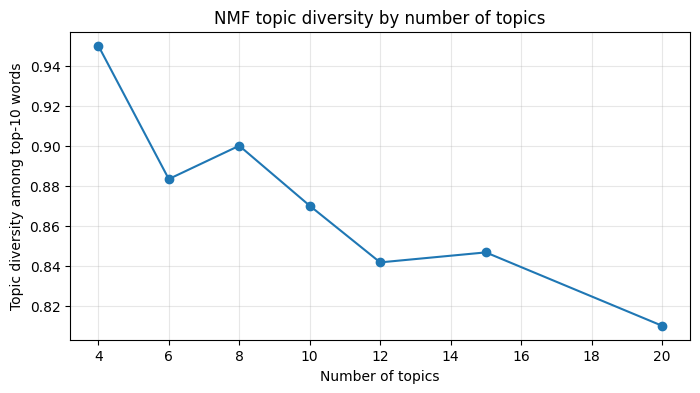

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(
    reconstruction_df["n_topics"],
    reconstruction_df["topic_diversity_top10"],
    marker="o"
)
plt.xlabel("Number of topics")
plt.ylabel("Topic diversity among top-10 words")
plt.title("NMF topic diversity by number of topics")
plt.grid(alpha=0.3)
plt.show()

## 7. Select the final number of topics

After inspecting several values, I select a final number of topics.

You can modify `FINAL_K` after looking at the topic tables. A good choice should produce topics that are:

- economically meaningful;
- not too redundant;
- specific enough to interpret;
- broad enough to remain stable over time.


In [17]:
# After inspecting the topics, choose the final number of topics.
# I start with 10 because it usually offers a good balance between detail and interpretability.

FINAL_K = 10
#K=8 ok mais ,.... et K=12 comence a creer topic geographique..

nmf_final = nmf_models[FINAL_K]["model"]
W_final = nmf_models[FINAL_K]["W"]
H_final = nmf_models[FINAL_K]["H"]

topic_words_final = topic_tables[FINAL_K]

display_topics(topic_words_final, FINAL_K)


Topic 0: inflation, monetary, monetary policy, rate, price, target, inflation target, expectation, forecast, low, riksbank, stability, high, inflation expectation, growth
Topic 1: risk, banking, capital, crisis, basel, institution, regulation, supervision, regulatory, credit, financial stability, supervisory, liquidity, management, stability
Topic 2: euro, euro area, area, european, ecb, union, monetary, country, europe, fiscal, monetary union, council, govern council, stability, reform
Topic 3: cent, country, exchange, global, growth, rate, exchange rate, foreign, crisis, trade, international, currency, world, south, capital
Topic 4: payment, digital, service, technology, fintech, innovation, card, cash, settlement, money, customer, payment service, transaction, cbdc, retail payment
Topic 5: federal, federal reserve, reserve, fomc, fed, percent, rate, labor, community, fund rate, federal fund, york, board federal, board, labor market
Topic 6: climate, climate change, green, risk, tran

## 8. Create a topic table for interpretation

I reshape the top words into a compact table, with one row per topic. This table will be useful for the report.


In [18]:
topic_summary = (
    topic_words_final
    .groupby("topic")["term"]
    .apply(lambda terms: ", ".join(terms.head(15)))
    .reset_index()
    .rename(columns={"term": "top_terms"})
)

topic_summary


,topic,top_terms
0,0,"inflation, monetary, monetary policy, rate, price, target, inflation target, expectation, forecast, low, riksbank, stability, high, inflation expectation, growth"
1,1,"risk, banking, capital, crisis, basel, institution, regulation, supervision, regulatory, credit, financial stability, supervisory, liquidity, management, stability"
2,2,"euro, euro area, area, european, ecb, union, monetary, country, europe, fiscal, monetary union, council, govern council, stability, reform"
3,3,"cent, country, exchange, global, growth, rate, exchange rate, foreign, crisis, trade, international, currency, world, south, capital"
4,4,"payment, digital, service, technology, fintech, innovation, card, cash, settlement, money, customer, payment service, transaction, cbdc, retail payment"
5,5,"federal, federal reserve, reserve, fomc, fed, percent, rate, labor, community, fund rate, federal fund, york, board federal, board, labor market"
6,6,"climate, climate change, green, risk, transition, climate relate, carbon, change, emission, climate risk, environmental, sustainable, relate, ngfs, energy"
7,7,"islamic, islamic finance, islamic financial, malaysia, shariah, finance, sukuk, islamic banking, industry, takaful, asia, institution, development, financial institution, malay..."
8,8,"japan, price, percent, growth, rate, increase, firm, decline, continue, chart, japan economy, demand, rise, labor, investment"
9,9,"bsp, financial inclusion, inclusion, philippine, banking, service, sector, albania, education, percent, financial service, microfinance, development, literacy, bangko"


### Manual topic labels

The model only returns topics as lists of words. I manually assign economic labels to topics after reading their top terms.

The labels below are placeholders. They should be edited after running the notebook and inspecting your actual topics.


In [31]:
manual_topic_labels = {
    0: "Inflation and monetary policy outlook",
    1: "Banking regulation and financial stability",
    2: "Euro area and European monetary union",
    3: "Global growth, trade and exchange rates",
    4: "Payments, fintech and digital finance",
    5: "Federal Reserve and US monetary policy",
    6: "Climate risk and sustainable finance",
    7: "Islamic finance and Malaysian financial system",
    8: "Japan economy and monetary easing",
    9: "Financial inclusion and development finance"
}

topic_summary["manual_label"] = topic_summary["topic"].map(manual_topic_labels)
topic_summary

topic_summary["manual_label"] = topic_summary["topic"].map(manual_topic_labels)
topic_summary


,topic,top_terms,manual_label
0,0,"inflation, monetary, monetary policy, rate, price, target, inflation target, expectation, forecast, low, riksbank, stability, high, inflation expectation, growth",Inflation and monetary policy outlook
1,1,"risk, banking, capital, crisis, basel, institution, regulation, supervision, regulatory, credit, financial stability, supervisory, liquidity, management, stability",Banking regulation and financial stability
2,2,"euro, euro area, area, european, ecb, union, monetary, country, europe, fiscal, monetary union, council, govern council, stability, reform",Euro area and European monetary union
3,3,"cent, country, exchange, global, growth, rate, exchange rate, foreign, crisis, trade, international, currency, world, south, capital","Global growth, trade and exchange rates"
4,4,"payment, digital, service, technology, fintech, innovation, card, cash, settlement, money, customer, payment service, transaction, cbdc, retail payment","Payments, fintech and digital finance"
5,5,"federal, federal reserve, reserve, fomc, fed, percent, rate, labor, community, fund rate, federal fund, york, board federal, board, labor market",Federal Reserve and US monetary policy
6,6,"climate, climate change, green, risk, transition, climate relate, carbon, change, emission, climate risk, environmental, sustainable, relate, ngfs, energy",Climate risk and sustainable finance
7,7,"islamic, islamic finance, islamic financial, malaysia, shariah, finance, sukuk, islamic banking, industry, takaful, asia, institution, development, financial institution, malay...",Islamic finance and Malaysian financial system
8,8,"japan, price, percent, growth, rate, increase, firm, decline, continue, chart, japan economy, demand, rise, labor, investment",Japan economy and monetary easing
9,9,"bsp, financial inclusion, inclusion, philippine, banking, service, sector, albania, education, percent, financial service, microfinance, development, literacy, bangko",Financial inclusion and development finance


## 9. Add NMF topic proportions to the dataset

The matrix `W_final` contains the topic intensity of each topic in each document.

I normalize it row-wise so that each document has topic proportions that sum to 1. This makes the results easier to interpret:

- a topic proportion close to 1 means the speech is strongly associated with that topic;
- a topic proportion close to 0 means the topic is almost absent from the speech.


In [32]:
W_normalized = normalize(W_final, norm="l1", axis=1)

topic_cols = [f"nmf_topic_{i}" for i in range(FINAL_K)]

df_nmf = df.copy()

for i, col in enumerate(topic_cols):
    df_nmf[col] = W_normalized[:, i]

df_nmf["nmf_dominant_topic"] = W_normalized.argmax(axis=1)
df_nmf["nmf_dominant_topic_label"] = df_nmf["nmf_dominant_topic"].map(manual_topic_labels)
df_nmf["nmf_dominant_topic_share"] = W_normalized.max(axis=1)

df_nmf[["year", "macro_period", "central_bank", "nmf_dominant_topic", "nmf_dominant_topic_share"] + topic_cols[:3]].head()


,year,macro_period,central_bank,nmf_dominant_topic,nmf_dominant_topic_share,nmf_topic_0,nmf_topic_1,nmf_topic_2
0,1997,Pre-GFC,bank of greece,3,0.520306,0.226411,0.000000,0.253283
1,1999,Pre-GFC,bank of greece,2,0.580246,0.108185,0.000000,0.580246
2,2001,Pre-GFC,bank of greece,2,0.851705,0.000000,0.000000,0.851705
3,2002,Pre-GFC,bank of greece,2,0.567002,0.056492,0.000000,0.567002
4,2002,Pre-GFC,bank of greece,2,0.382848,0.000000,0.283001,0.382848


## 10. Dominant topic distribution

I first check how many speeches are assigned to each dominant topic. A very large imbalance may indicate that some topics are too broad or that the number of topics should be adjusted.


In [33]:
dominant_topic_counts = (
    df_nmf["nmf_dominant_topic"]
    .value_counts()
    .sort_index()
    .reset_index()
)

dominant_topic_counts.columns = ["topic", "n_speeches"]
dominant_topic_counts["manual_label"] = dominant_topic_counts["topic"].map(manual_topic_labels)
dominant_topic_counts


,topic,n_speeches,manual_label
0,0,2023,Inflation and monetary policy outlook
1,1,3654,Banking regulation and financial stability
2,2,2698,Euro area and European monetary union
3,3,2694,"Global growth, trade and exchange rates"
4,4,1106,"Payments, fintech and digital finance"
5,5,1369,Federal Reserve and US monetary policy
6,6,591,Climate risk and sustainable finance
7,7,324,Islamic finance and Malaysian financial system
8,8,1583,Japan economy and monetary easing
9,9,2880,Financial inclusion and development finance


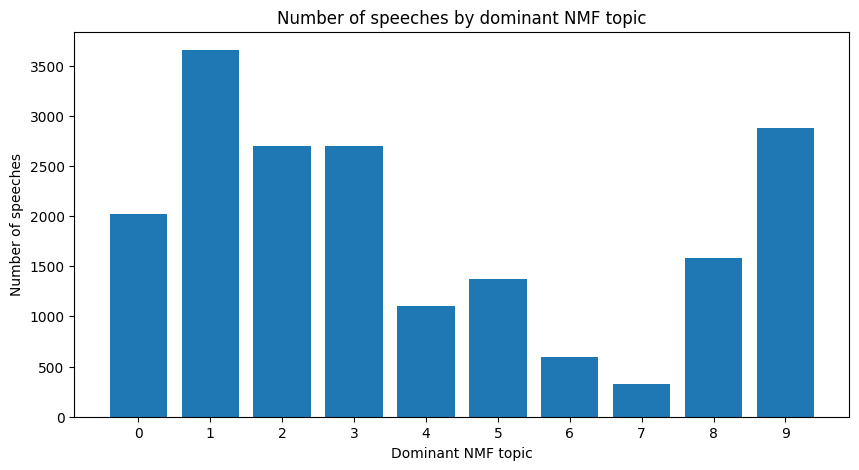

In [34]:
plt.figure(figsize=(10, 5))
plt.bar(dominant_topic_counts["topic"].astype(str), dominant_topic_counts["n_speeches"])
plt.xlabel("Dominant NMF topic")
plt.ylabel("Number of speeches")
plt.title("Number of speeches by dominant NMF topic")
plt.show()


## 11. Topic prevalence over time

I compute the average topic proportion by year. This is better than raw counts because the number of speeches varies across years.


In [35]:
topic_by_year = (
    df_nmf
    .groupby("year")[topic_cols]
    .mean()
    .reset_index()
)

topic_by_year.head()


,year,nmf_topic_0,nmf_topic_1,nmf_topic_2,nmf_topic_3,nmf_topic_4,nmf_topic_5,nmf_topic_6,nmf_topic_7,nmf_topic_8,nmf_topic_9
0,1997,0.143619,0.135691,0.092672,0.222373,0.075694,0.104057,0.019419,0.011287,0.146541,0.048647
1,1998,0.119211,0.180256,0.117351,0.270147,0.069296,0.076571,0.012222,0.011727,0.115758,0.027461
2,1999,0.146367,0.162527,0.188715,0.208024,0.062292,0.062169,0.013692,0.012037,0.109963,0.034214
3,2000,0.160475,0.140716,0.175579,0.177313,0.070979,0.049213,0.016872,0.012340,0.145288,0.051226
4,2001,0.151983,0.145877,0.170862,0.177286,0.067797,0.066091,0.013892,0.010763,0.140198,0.055251


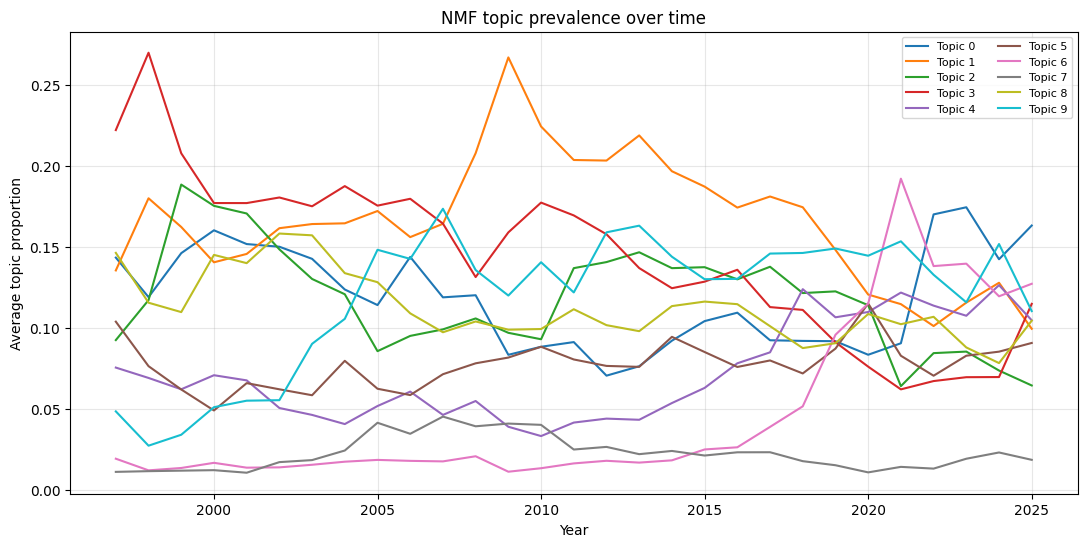

In [36]:
plt.figure(figsize=(13, 6))

for i, col in enumerate(topic_cols):
    plt.plot(topic_by_year["year"], topic_by_year[col], label=f"Topic {i}")

plt.xlabel("Year")
plt.ylabel("Average topic proportion")
plt.title("NMF topic prevalence over time")
plt.legend(ncol=2, fontsize=8)
plt.grid(alpha=0.3)
plt.show()


The figure shows how the average prevalence of each topic changes over time. This will help identify whether some themes become more important during specific macro-financial regimes.


## 12. Topic prevalence by macro-financial period

I also compute the average topic proportion by macro-financial period. This gives a more economic interpretation of the topics.


In [37]:
period_order = [
    "Pre-GFC",
    "Global Financial Crisis",
    "Euro crisis / post-GFC",
    "Low rates / QE",
    "Covid",
    "Inflation tightening"
]

topic_by_period = (
    df_nmf
    .groupby("macro_period")[topic_cols]
    .mean()
    .reindex(period_order)
)

topic_by_period


,nmf_topic_0,nmf_topic_1,nmf_topic_2,nmf_topic_3,nmf_topic_4,nmf_topic_5,nmf_topic_6,nmf_topic_7,nmf_topic_8,nmf_topic_9
macro_period,,,,,,,,,,
Pre-GFC,0.137750,0.159883,0.125632,0.188754,0.057126,0.066001,0.016519,0.023498,0.132416,0.092419
Global Financial Crisis,0.107811,0.213140,0.100875,0.151652,0.046956,0.077270,0.016734,0.041976,0.100291,0.143294
Euro crisis / post-GFC,0.083873,0.209848,0.131171,0.153253,0.043269,0.083266,0.016709,0.027651,0.104890,0.146070
Low rates / QE,0.097612,0.172729,0.129860,0.115018,0.092557,0.080300,0.049226,0.020136,0.101452,0.141111
Covid,0.087096,0.117902,0.089740,0.069403,0.115899,0.099470,0.153002,0.012641,0.105714,0.149133
Inflation tightening,0.162834,0.114613,0.081124,0.069907,0.115709,0.079902,0.132737,0.018601,0.091641,0.132933


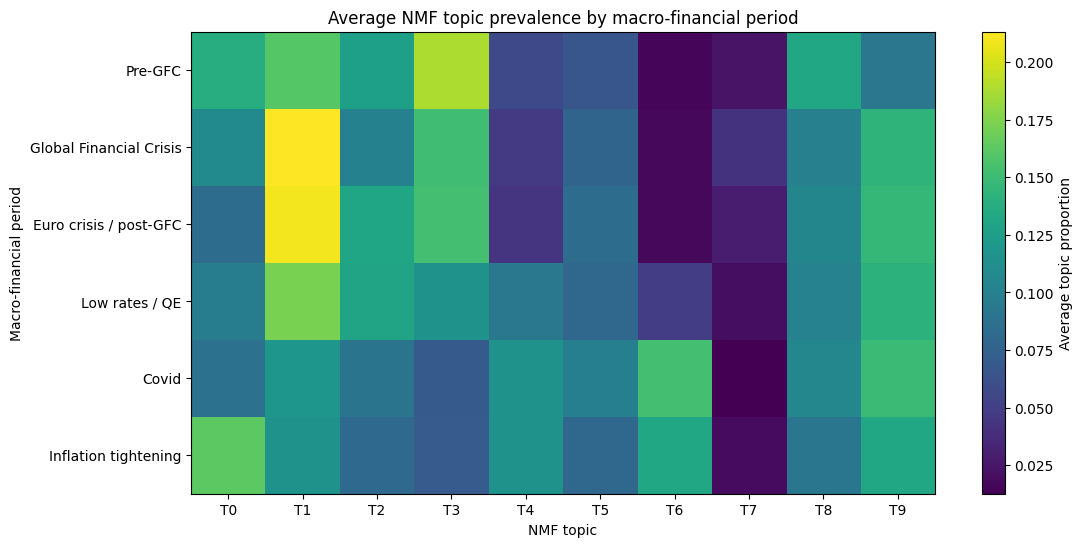

In [38]:
plt.figure(figsize=(12, 6))
plt.imshow(topic_by_period.values, aspect="auto")
plt.colorbar(label="Average topic proportion")
plt.xticks(range(FINAL_K), [f"T{i}" for i in range(FINAL_K)])
plt.yticks(range(len(topic_by_period.index)), topic_by_period.index)
plt.xlabel("NMF topic")
plt.ylabel("Macro-financial period")
plt.title("Average NMF topic prevalence by macro-financial period")
plt.show()


This heatmap highlights which topics are more present in each macro-financial period. For example, a topic related to financial stability may be stronger during the global financial crisis, while an inflation or rate-hike topic may be stronger during the inflation tightening period.


## 13. Most representative speeches per topic

To interpret topics more carefully, I inspect the speeches with the highest topic proportion for each topic. This helps verify whether the top words correspond to meaningful documents.


In [39]:
def show_representative_speeches(df, topic_id, n=3):
    topic_col = f"nmf_topic_{topic_id}"
    cols = ["description", "central_bank", "year", "macro_period", topic_col, "raw_text_stripped"]

    return (
        df.sort_values(topic_col, ascending=False)
        [cols]
        .head(n)
    )

# Example: inspect topic 0
show_representative_speeches(df_nmf, topic_id=0, n=3)


,description,central_bank,year,macro_period,nmf_topic_0,raw_text_stripped
16317,"Speech by Ms Irma Rosenberg, Deputy Governor of the Sveriges Riksbank, at the CPI committee's 50th anniversary, Norra Latin, 4 May 2004.",sveriges riksbank,2004,Pre-GFC,1.000000,"Irma Rosenberg: The inflation target and the CPI Speech by Ms Irma Rosenberg, Deputy Governor of the Sveriges Riksbank, at the CPI committee’s 50th anniversary, Norra Latin, 4 ..."
11419,"Notes by Mr Aleš Michl, Governor of the Czech National Bank, at the General Council Meeting, Frankfurt am Main, 26 September 2024.",czech national bank,2024,Inflation tightening,1.000000,"Governor’s notes on the inflation expectations of households Prepared for the discussion at the General Council Meeting on 26 September 2024 Aleš Michl Good morning, President ..."
16570,"Speech by Mr Martin Flodén, Deputy Governor of the Sveriges Riksbank, at Fores, Stockholm, 13 October 2015",sveriges riksbank,2015,Low rates / QE,0.994341,"Martin Flodén: Sweden needs its inflation target Speech by Mr Martin Flodén, Deputy Governor of the Sveriges Riksbank, at Fores, Stockholm, 13 October 2015. * * * I would like ..."


Run the function above for different topics to manually validate the interpretation of each topic.


In [40]:
# Example loop: print the top description for each topic
for topic_id in range(FINAL_K):
    topic_col = f"nmf_topic_{topic_id}"
    top_row = df_nmf.sort_values(topic_col, ascending=False).iloc[0]
    print("=" * 80)
    print(f"Topic {topic_id}")
    print("Top terms:", topic_summary.loc[topic_summary["topic"] == topic_id, "top_terms"].values[0])
    print("Most representative speech:")
    print("Year:", top_row["year"])
    print("Bank:", top_row["central_bank"])
    print("Description:", top_row["description"])


Topic 0
Top terms: inflation, monetary, monetary policy, rate, price, target, inflation target, expectation, forecast, low, riksbank, stability, high, inflation expectation, growth
Most representative speech:
Year: 2004
Bank: sveriges riksbank
Description: Speech by Ms Irma Rosenberg, Deputy Governor of the Sveriges Riksbank, at the CPI committee's 50th anniversary, Norra Latin, 4 May 2004.
Topic 1
Top terms: risk, banking, capital, crisis, basel, institution, regulation, supervision, regulatory, credit, financial stability, supervisory, liquidity, management, stability
Most representative speech:
Year: 2004
Bank: european central bank
Description: Opening remarks of Mr Jean-Claude Trichet, President of the European Central Bank and Chairman of the G10 Governors and Heads of Supervision, at the Press Conference announcing the publication of Basel II, Bank for International Settlements, Basel, 26 June 2004.
Topic 2
Top terms: euro, euro area, area, european, ecb, union, monetary, countr

## 14. Save NMF outputs

I save the dataset with NMF topic proportions and the topic summary table. These files will be used later for comparison with LDA, BERTopic, and hawkish/dovish tone analysis.


In [41]:
df_nmf.to_csv("bis_speeches_with_nmf_topics.csv", index=False)
topic_summary.to_csv("nmf_topic_summary.csv", index=False)
topic_words_final.to_csv("nmf_topic_top_words_long.csv", index=False)

print("Saved: bis_speeches_with_nmf_topics.csv")
print("Saved: nmf_topic_summary.csv")
print("Saved: nmf_topic_top_words_long.csv")
print("Final dataset shape:", df_nmf.shape)


Saved: bis_speeches_with_nmf_topics.csv
Saved: nmf_topic_summary.csv
Saved: nmf_topic_top_words_long.csv
Final dataset shape: (18922, 24)


In [42]:
from google.colab import files

files.download("bis_speeches_with_nmf_topics.csv")
files.download("nmf_topic_summary.csv")
files.download("nmf_topic_top_words_long.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 15. Conclusion of this notebook

This notebook built an interpretable topic modeling baseline using TF-IDF and NMF. The TF-IDF representation emphasizes terms that are specific to subsets of speeches, while NMF decomposes the document-term matrix into document-topic and topic-term matrices.

The final number of topics is selected using a combination of reconstruction error, topic diversity and qualitative interpretability. The topic labels are assigned manually after inspecting the top terms and the most representative speeches for each topic.

The resulting NMF topic proportions can be used to study the evolution of central bank communication over time and across macro-financial periods. The next notebook compares these results with LDA, a probabilistic topic model based on word counts rather than TF-IDF weights.